In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "bold",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "DailyDelhiClimate.csv"

df = pd.read_csv(file_path)
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .drop_duplicates(subset="date")
      .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

display(df.head())

Rows: 1,575
Columns: 5
Date range: 2013-01-01 → 2017-04-24


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000,84.500,0.000,"1,015.667"
1,2013-01-02,7.400,92.000,2.980,"1,017.800"
2,2013-01-03,7.167,87.000,4.633,"1,018.667"
3,2013-01-04,8.667,71.333,1.233,"1,017.167"
4,2013-01-05,6.000,86.833,3.700,"1,016.500"


In [3]:
print("Data types")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values")
display(df.isna().sum().to_frame("missing_values"))

print("\nSummary statistics")
display(df.describe().T)

Data types


,dtype
date,datetime64[ns]
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64



Missing values


,missing_values
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0



Summary statistics


,count,mean,min,25%,50%,75%,max,std
date,1575,2015-02-27 00:00:00,2013-01-01 00:00:00,2014-01-29 12:00:00,2015-02-27 00:00:00,2016-03-26 12:00:00,2017-04-24 00:00:00,NaN
meantemp,"1,575.000",25.228,6.000,18.517,27.167,31.143,38.714,7.344
humidity,"1,575.000",60.429,13.429,49.750,62.381,72.125,100.000,16.973
wind_speed,"1,575.000",6.902,0.000,3.700,6.370,9.262,42.220,4.511
meanpressure,"1,575.000","1,011.197",-3.042,"1,001.875","1,009.111","1,015.200","7,679.333",173.649


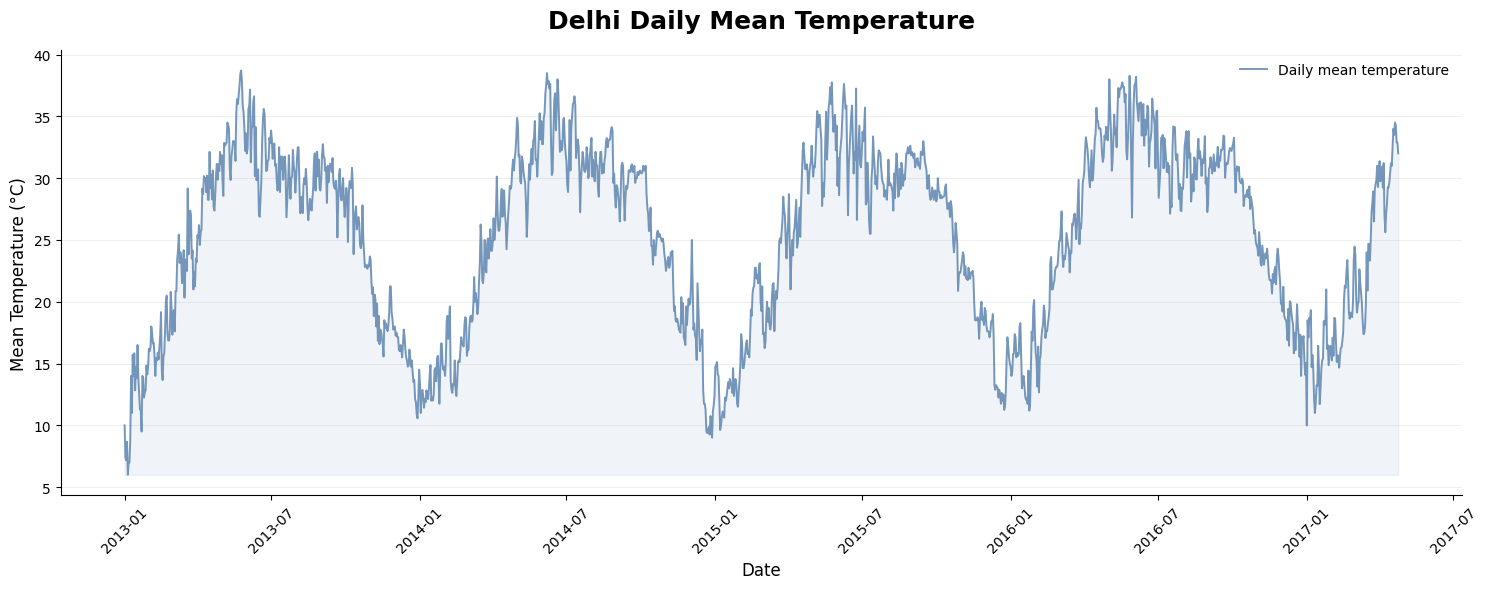

In [4]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    df["date"],
    df["meantemp"],
    linewidth=1.4,
    color="#4C78A8",
    alpha=0.75,
    label="Daily mean temperature"
)

ax.fill_between(
    df["date"],
    df["meantemp"],
    df["meantemp"].min(),
    color="#4C78A8",
    alpha=0.08
)

ax.set_title("Delhi Daily Mean Temperature", pad=16)
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.grid(axis="y", alpha=0.20)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [5]:
def ewma_manual(values, beta=0.9, initial=None):
    """
    Compute EWMA recursively using the beta convention:

        EWMA_t = beta * EWMA_(t-1) + (1-beta) * x_t

    Parameters
    ----------
    values : array-like
        Time-series observations.
    beta : float
        Value from 0 to 1 controlling historical memory.
    initial : float or None
        Initial EWMA value. Defaults to the first observation.

    Returns
    -------
    numpy.ndarray
        EWMA values.
    """
    values = np.asarray(values, dtype=float)

    if not 0 <= beta <= 1:
        raise ValueError("beta must be between 0 and 1.")

    if values.size == 0:
        return np.array([])

    result = np.empty_like(values)

    result[0] = values[0] if initial is None else initial

    for t in range(1, len(values)):
        result[t] = beta * result[t - 1] + (1 - beta) * values[t]

    return result


beta = 0.90
df["ewma_manual_beta_090"] = ewma_manual(df["meantemp"], beta=beta)

display(
    df[["date", "meantemp", "ewma_manual_beta_090"]].head(10)
)

,date,meantemp,ewma_manual_beta_090
0,2013-01-01,10.000,10.000
1,2013-01-02,7.400,9.740
2,2013-01-03,7.167,9.483
3,2013-01-04,8.667,9.401
4,2013-01-05,6.000,9.061
5,2013-01-06,7.000,8.855
6,2013-01-07,7.000,8.669
7,2013-01-08,8.857,8.688
8,2013-01-09,14.000,9.219
9,2013-01-10,11.000,9.397


In [6]:
example = pd.DataFrame({
    "x_t": [10, 12, 15, 13, 18]
})

beta = 0.80
example["EWMA_manual"] = ewma_manual(example["x_t"], beta=beta)

example["calculation"] = [
    "EWMA₀ = x₀",
    f"{beta:.2f} × EWMA₀ + {(1-beta):.2f} × x₁",
    f"{beta:.2f} × EWMA₁ + {(1-beta):.2f} × x₂",
    f"{beta:.2f} × EWMA₂ + {(1-beta):.2f} × x₃",
    f"{beta:.2f} × EWMA₃ + {(1-beta):.2f} × x₄",
]

display(example)

,x_t,EWMA_manual,calculation
0,10,10.000,EWMA₀ = x₀
1,12,10.400,0.80 × EWMA₀ + 0.20 × x₁
2,15,11.320,0.80 × EWMA₁ + 0.20 × x₂
3,13,11.656,0.80 × EWMA₂ + 0.20 × x₃
4,18,12.925,0.80 × EWMA₃ + 0.20 × x₄


In [7]:
beta = 0.90
alpha = 1 - beta

manual = ewma_manual(df["meantemp"], beta=beta)

pandas_ewma = (
    df["meantemp"]
      .ewm(alpha=alpha, adjust=False)
      .mean()
      .to_numpy()
)

comparison = pd.DataFrame({
    "manual": manual,
    "pandas": pandas_ewma
})

comparison["absolute_difference"] = (
    comparison["manual"] - comparison["pandas"]
).abs()

print(
    "Maximum absolute difference:",
    f"{comparison['absolute_difference'].max():.12f}"
)

display(comparison.head(10))

Maximum absolute difference: 0.000000000000


,manual,pandas,absolute_difference
0,10.000,10.000,0.000
1,9.740,9.740,0.000
2,9.483,9.483,0.000
3,9.401,9.401,0.000
4,9.061,9.061,0.000
5,8.855,8.855,0.000
6,8.669,8.669,0.000
7,8.688,8.688,0.000
8,9.219,9.219,0.000
9,9.397,9.397,0.000


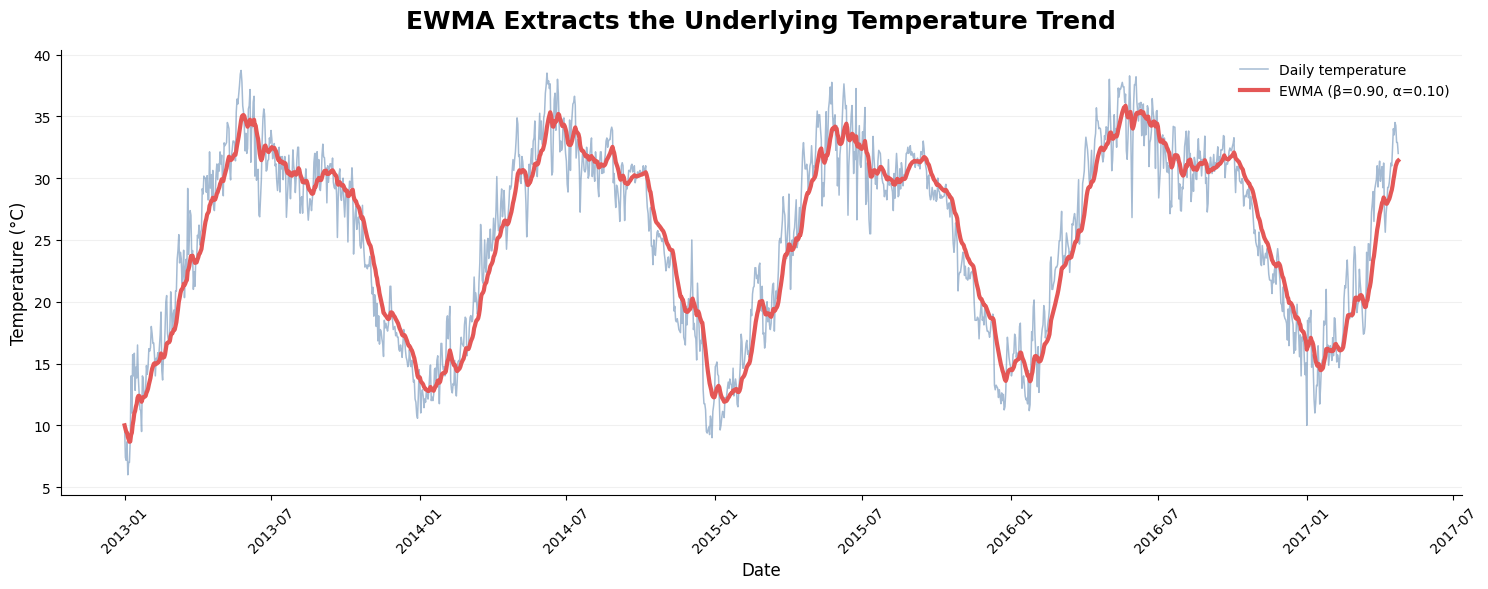

In [8]:
beta = 0.90
alpha = 1 - beta

df["EWMA_beta_090"] = (
    df["meantemp"]
      .ewm(alpha=alpha, adjust=False)
      .mean()
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    df["date"],
    df["meantemp"],
    color="#4C78A8",
    linewidth=1.1,
    alpha=0.50,
    label="Daily temperature"
)

ax.plot(
    df["date"],
    df["EWMA_beta_090"],
    color="#E45756",
    linewidth=3.0,
    label=f"EWMA (β={beta:.2f}, α={alpha:.2f})"
)

ax.set_title("EWMA Extracts the Underlying Temperature Trend", pad=16)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", alpha=0.18)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

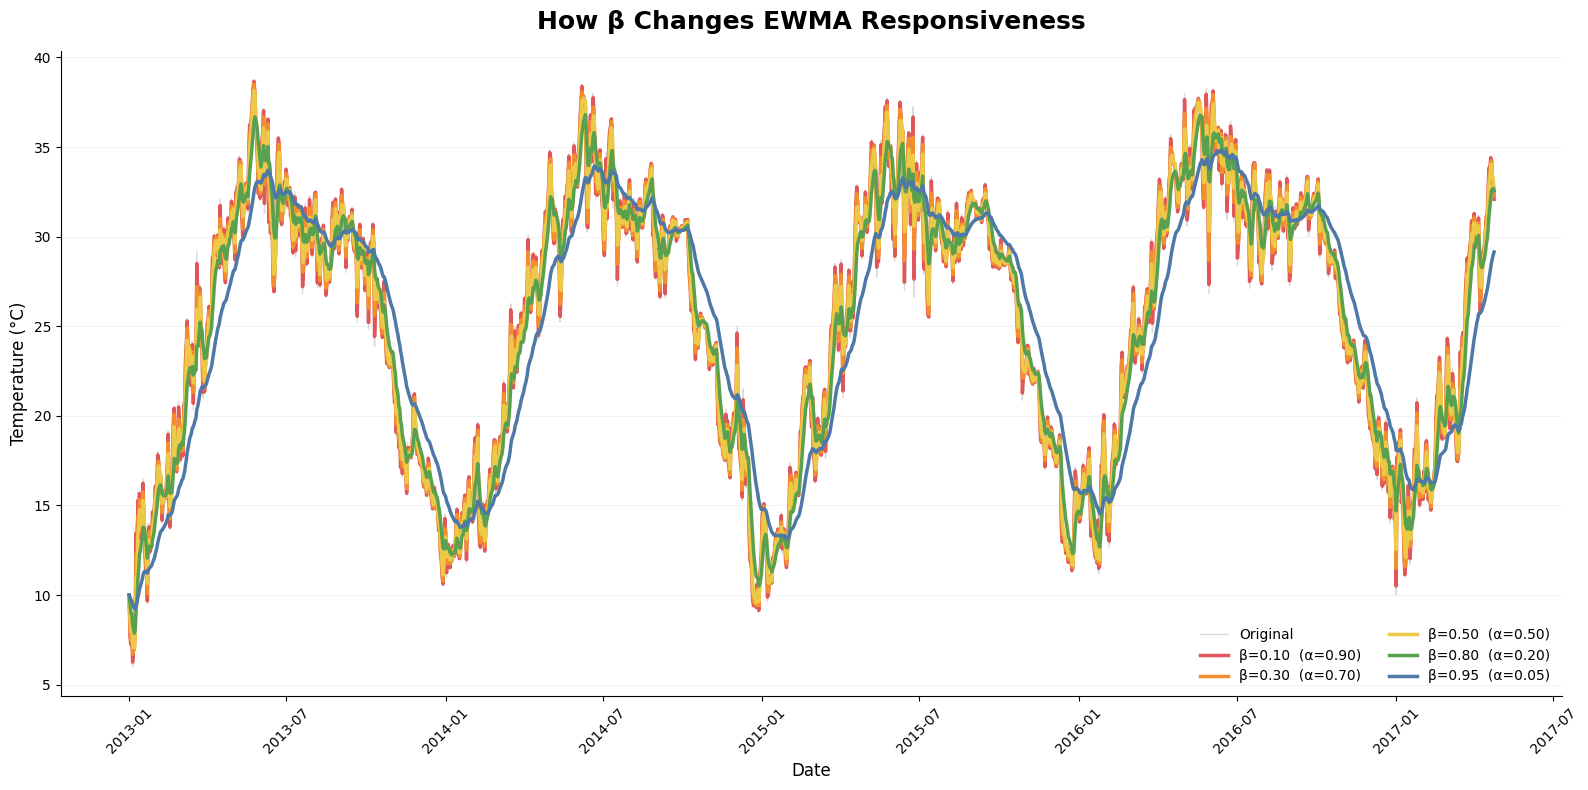

In [9]:
beta_values = [0.10, 0.30, 0.50, 0.80, 0.95]
palette = ["#E15759", "#F28E2B", "#EDC948", "#59A14F", "#4E79A7"]

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(
    df["date"],
    df["meantemp"],
    color="#B0B0B0",
    linewidth=1,
    alpha=0.45,
    label="Original"
)

for beta, color in zip(beta_values, palette):
    alpha = 1 - beta
    ewma = df["meantemp"].ewm(
        alpha=alpha,
        adjust=False
    ).mean()

    ax.plot(
        df["date"],
        ewma,
        linewidth=2.5,
        color=color,
        label=f"β={beta:.2f}  (α={alpha:.2f})"
    )

ax.set_title("How β Changes EWMA Responsiveness", pad=16)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", alpha=0.15)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

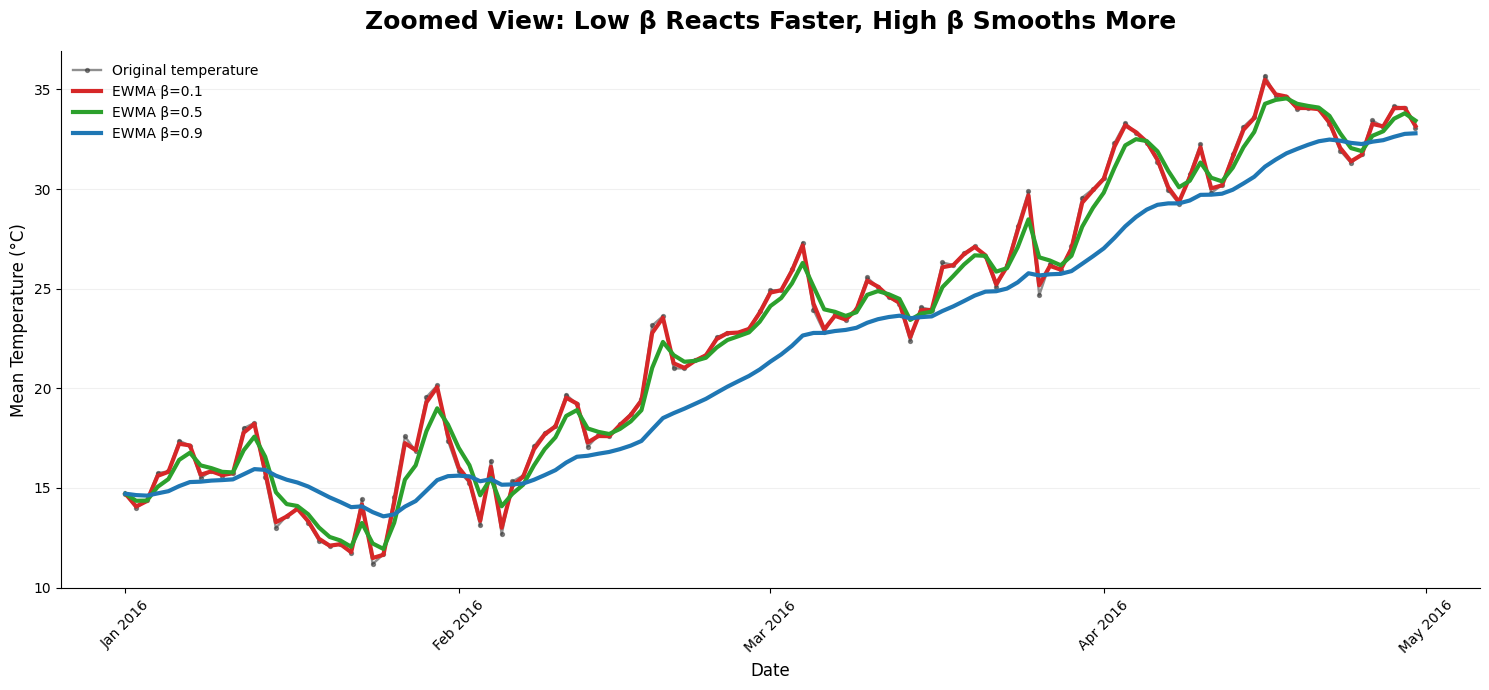

In [10]:
start_date = "2016-01-01"
end_date = "2016-04-30"

zoom = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
].copy()

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    zoom["date"],
    zoom["meantemp"],
    color="#333333",
    linewidth=1.7,
    marker="o",
    markersize=2.8,
    alpha=0.55,
    label="Original temperature"
)

zoom_betas = [0.10, 0.50, 0.90]
zoom_colors = ["#D62728", "#2CA02C", "#1F77B4"]

for beta, color in zip(zoom_betas, zoom_colors):
    alpha = 1 - beta
    ewma = zoom["meantemp"].ewm(
        alpha=alpha,
        adjust=False
    ).mean()

    ax.plot(
        zoom["date"],
        ewma,
        color=color,
        linewidth=3,
        label=f"EWMA β={beta:.1f}"
    )

ax.set_title("Zoomed View: Low β Reacts Faster, High β Smooths More", pad=16)
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.grid(axis="y", alpha=0.18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

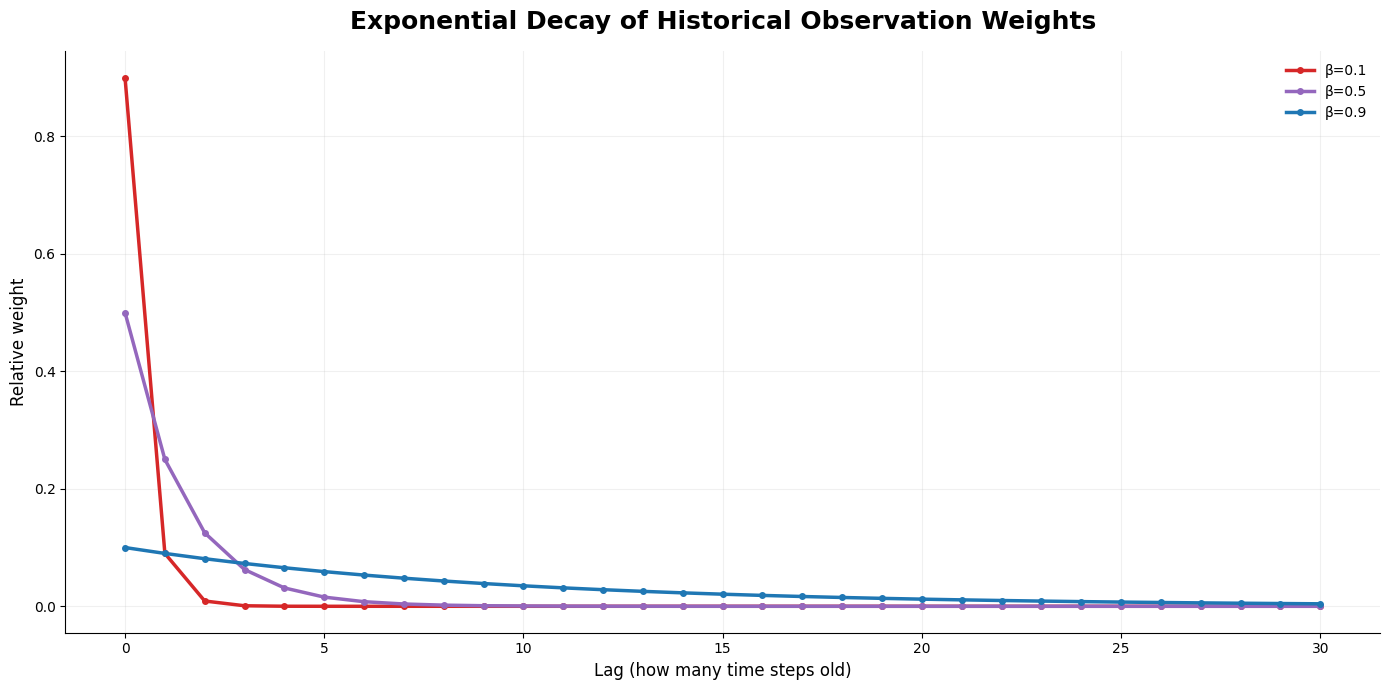

In [11]:
betas_for_weights = [0.10, 0.50, 0.90]
lags = np.arange(0, 31)
weight_colors = ["#D62728", "#9467BD", "#1F77B4"]

fig, ax = plt.subplots(figsize=(14, 7))

for beta, color in zip(betas_for_weights, weight_colors):
    weights = (1 - beta) * (beta ** lags)

    ax.plot(
        lags,
        weights,
        marker="o",
        markersize=4,
        linewidth=2.5,
        color=color,
        label=f"β={beta:.1f}"
    )

ax.set_title("Exponential Decay of Historical Observation Weights", pad=16)
ax.set_xlabel("Lag (how many time steps old)")
ax.set_ylabel("Relative weight")
ax.grid(alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [12]:
beta = 0.80
alpha = 1 - beta

lags = np.arange(10)
weights = alpha * (beta ** lags)

weight_table = pd.DataFrame({
    "lag": lags,
    "weight": weights,
    "percentage": weights * 100
})

display(weight_table)

print(
    f"Sum of first 10 approximate weights: {weights.sum():.4f}"
)

,lag,weight,percentage
0,0,0.200,20.000
1,1,0.160,16.000
2,2,0.128,12.800
3,3,0.102,10.240
4,4,0.082,8.192
5,5,0.066,6.554
6,6,0.052,5.243
7,7,0.042,4.194
8,8,0.034,3.355
9,9,0.027,2.684


Sum of first 10 approximate weights: 0.8926


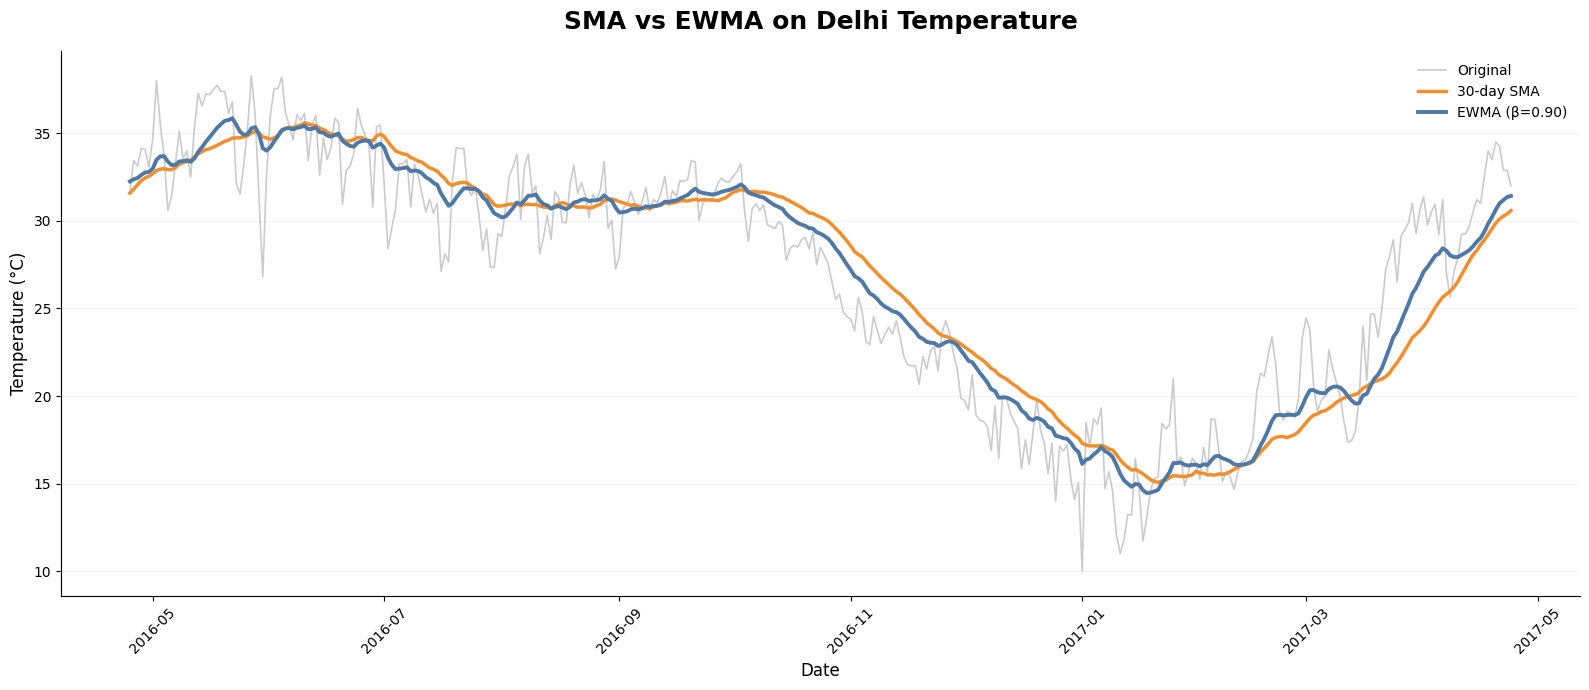

In [13]:
window = 30

df["SMA_30"] = df["meantemp"].rolling(
    window=window
).mean()

beta = 0.90

df["EWMA_beta_090"] = (
    df["meantemp"]
      .ewm(alpha=1-beta, adjust=False)
      .mean()
)

recent = df.tail(365)

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    recent["date"],
    recent["meantemp"],
    color="#B0B0B0",
    linewidth=1.2,
    alpha=0.65,
    label="Original"
)

ax.plot(
    recent["date"],
    recent["SMA_30"],
    color="#F28E2B",
    linewidth=2.5,
    label="30-day SMA"
)

ax.plot(
    recent["date"],
    recent["EWMA_beta_090"],
    color="#4E79A7",
    linewidth=2.8,
    label="EWMA (β=0.90)"
)

ax.set_title("SMA vs EWMA on Delhi Temperature", pad=16)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", alpha=0.15)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [14]:
beta_values = [0.10, 0.30, 0.50, 0.70, 0.90, 0.95, 0.99]

rows = []

for beta in beta_values:
    ewma = df["meantemp"].ewm(
        alpha=1-beta,
        adjust=False
    ).mean()

    error = df["meantemp"] - ewma

    rows.append({
        "beta": beta,
        "alpha": 1 - beta,
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "Correlation": df["meantemp"].corr(ewma)
    })

beta_metrics = pd.DataFrame(rows)

display(beta_metrics.round(4))

,beta,alpha,MAE,RMSE,Correlation
0,0.100,0.900,0.124,0.166,1.000
1,0.300,0.700,0.375,0.498,0.998
2,0.500,0.500,0.652,0.853,0.993
3,0.700,0.300,0.999,1.287,0.985
4,0.900,0.100,1.728,2.154,0.956
5,0.950,0.050,2.536,3.097,0.907
6,0.990,0.010,5.642,6.724,0.457


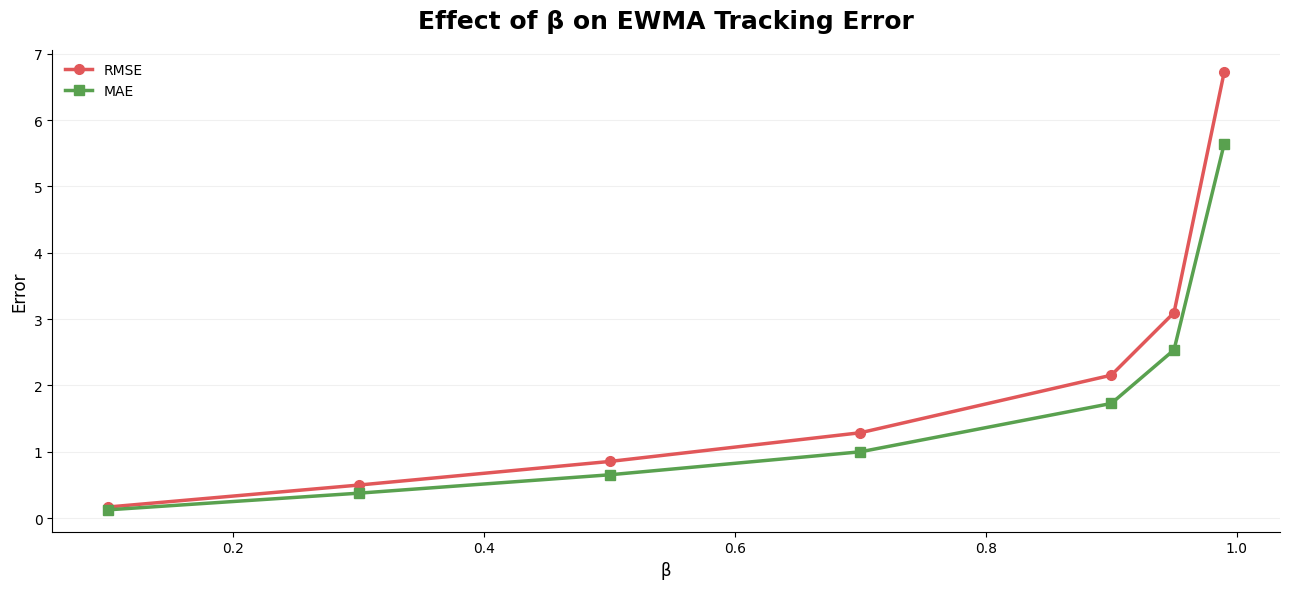

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    beta_metrics["beta"],
    beta_metrics["RMSE"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#E15759",
    label="RMSE"
)

ax.plot(
    beta_metrics["beta"],
    beta_metrics["MAE"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="#59A14F",
    label="MAE"
)

ax.set_title("Effect of β on EWMA Tracking Error", pad=16)
ax.set_xlabel("β")
ax.set_ylabel("Error")
ax.grid(axis="y", alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

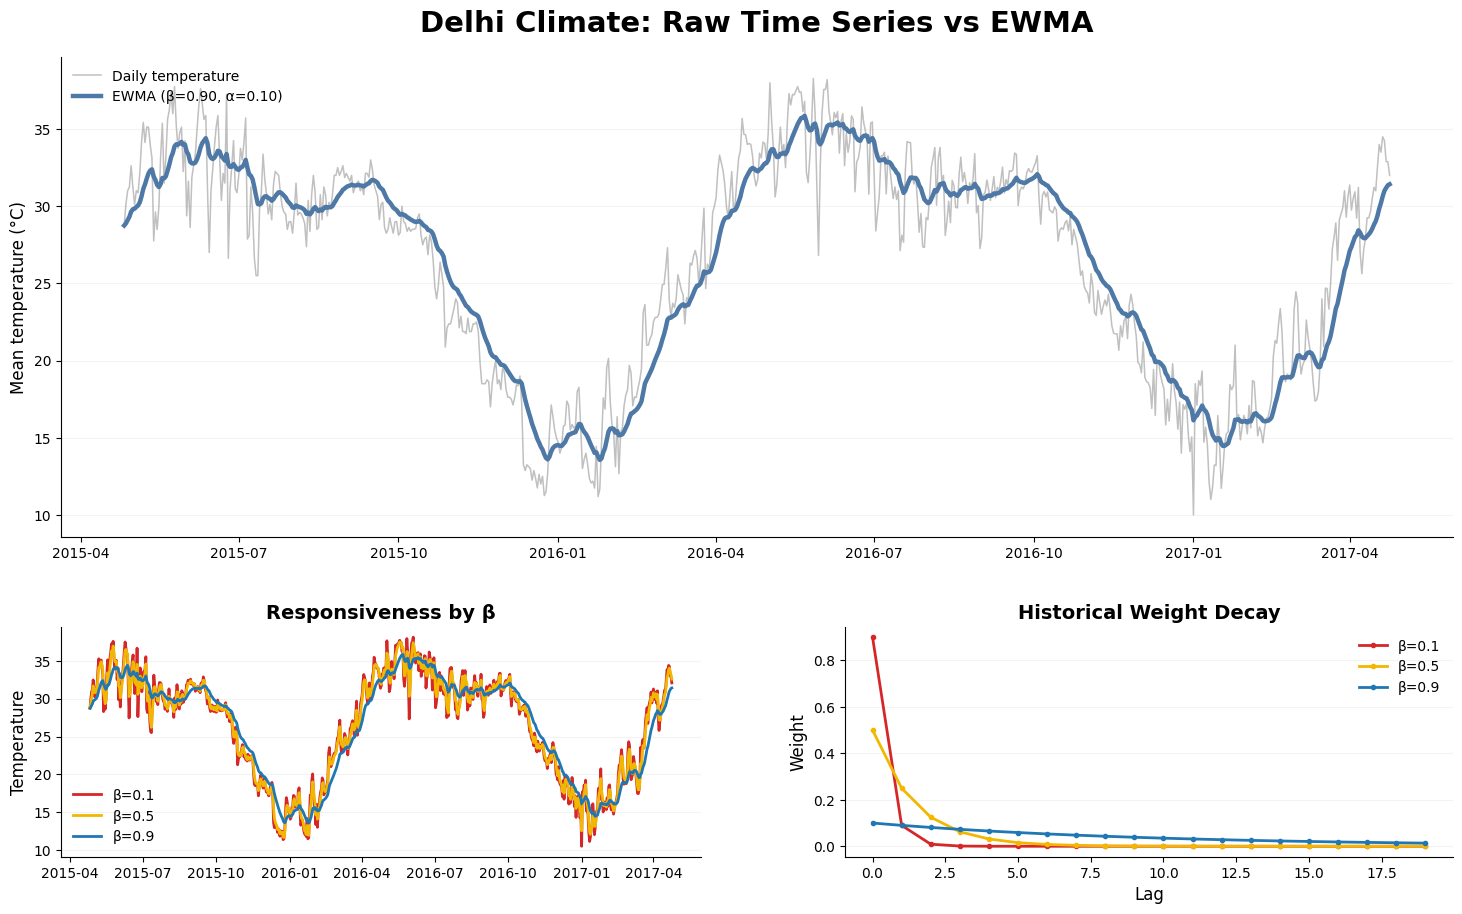

In [16]:
beta = 0.90
alpha = 1 - beta

plot_df = df.tail(730).copy()

plot_df["EWMA"] = (
    plot_df["meantemp"]
    .ewm(alpha=alpha, adjust=False)
    .mean()
)

fig = plt.figure(figsize=(16, 10))

# Main chart
ax = fig.add_axes([0.08, 0.42, 0.87, 0.48])

ax.plot(
    plot_df["date"],
    plot_df["meantemp"],
    linewidth=1.1,
    color="#9E9E9E",
    alpha=0.65,
    label="Daily temperature"
)

ax.plot(
    plot_df["date"],
    plot_df["EWMA"],
    linewidth=3.2,
    color="#4E79A7",
    label=f"EWMA (β={beta:.2f}, α={alpha:.2f})"
)

ax.set_title(
    "Delhi Climate: Raw Time Series vs EWMA",
    fontsize=21,
    pad=18,
    fontweight="bold"
)

ax.set_ylabel("Mean temperature (°C)")
ax.grid(axis="y", alpha=0.15)
ax.legend(frameon=False, loc="upper left")

# Bottom-left chart
ax2 = fig.add_axes([0.08, 0.10, 0.40, 0.23])

for beta, color in zip(
    [0.10, 0.50, 0.90],
    ["#D62728", "#F2B701", "#1F77B4"]
):
    ax2.plot(
        plot_df["date"],
        plot_df["meantemp"].ewm(
            alpha=1-beta,
            adjust=False
        ).mean(),
        linewidth=2,
        color=color,
        label=f"β={beta}"
    )

ax2.set_title("Responsiveness by β", fontsize=14, fontweight="bold")
ax2.set_ylabel("Temperature")
ax2.grid(axis="y", alpha=0.15)
ax2.legend(frameon=False)

# Bottom-right chart
ax3 = fig.add_axes([0.57, 0.10, 0.38, 0.23])

lags = np.arange(0, 20)

for beta, color in zip(
    [0.10, 0.50, 0.90],
    ["#D62728", "#F2B701", "#1F77B4"]
):
    weights = (1-beta) * beta**lags

    ax3.plot(
        lags,
        weights,
        marker="o",
        markersize=3,
        linewidth=2,
        color=color,
        label=f"β={beta}"
    )

ax3.set_title(
    "Historical Weight Decay",
    fontsize=14,
    fontweight="bold"
)
ax3.set_xlabel("Lag")
ax3.set_ylabel("Weight")
ax3.grid(axis="y", alpha=0.15)
ax3.legend(frameon=False)

plt.show()